# Objective
To build a convolutional Autoencoder (CAE) that compresses facial images into a lower dimensional latent representation and then reconstructs them with minimal loss of information

# Purpose

A convolutional autoencoder is an unsupervised deep learning model used for :
Image compression image reconstruction feature extraction dimensionality reduction
the encoder learns a compressed representation (latent space),while the decoder learns to reconstruct the original image from this compressed representation


In [ ]:
# Libraries
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [ ]:
# Loading dataset

import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


In [ ]:
# create a smaller dataset
source_folder = os.path.join(path, 'img_align_celeba', 'img_align_celeba')
destination_folder = "celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images = sorted(os.listdir(source_folder))[:5000]
for img in images:
    shutil.copy(
        os.path.join(source_folder, img),
        destination_folder
        )

print("Copied", len(images),"images")


Copied 5000 images


In [ ]:
# # Upload kaggle API
# from google.colab import files
# files.upload()

In [ ]:
# DATA PREPROCESSING
IMAGE_SIZE = (64,64)

BATCH_SIZE = 32

In [ ]:
datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.2
)

In [ ]:
train_generator = datagen.flow_from_directory(

  "celeba_small",
  target_size = IMAGE_SIZE,
  batch_size = BATCH_SIZE,
  class_mode = "input",
  subset = "training"
)

Found 4000 images belonging to 1 classes.


In [ ]:
validation_generator = datagen.flow_from_directory(

  "celeba_small",
  target_size = IMAGE_SIZE,
  batch_size = BATCH_SIZE,
  class_mode = "input",
  subset = "validation"
)

Found 1000 images belonging to 1 classes.


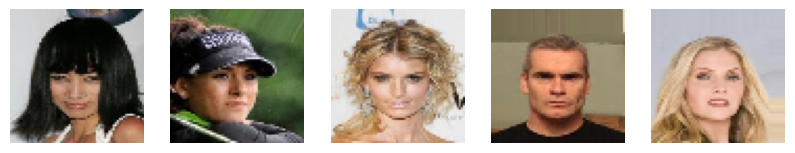

In [ ]:
# display sample images

images, _ = next(train_generator)
plt.figure(figsize=(10,5))

for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [ ]:
# build Convolutional Autoencoder
input_img = Input(shape=(64,64,3))

# Block 1
x = Conv2D(32,(3,3),padding='same',kernel_initializer='he_normal')(input_img)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

x = Conv2D(32,(3,3),padding='same',kernel_initializer='he_normal')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

x = MaxPooling2D((2,2),padding='same')(x)

# Block 2
x = Conv2D(64,(3,3),padding='same',kernel_initializer='he_normal')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

x = Conv2D(64,(3,3),padding='same',kernel_initializer='he_normal')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

encoded = MaxPooling2D((2,2),padding='same')(x)


In [ ]:

# Decoder


x = tf.keras.layers.Conv2DTranspose(
    64,(3,3),strides=2,padding='same'
)(encoded)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

x = Conv2D(64,(3,3),padding='same',activation='relu')(x)

x = tf.keras.layers.Conv2DTranspose(
    32,(3,3),strides=2,padding='same'
)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

decoded = Conv2D(
    3,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

In [ ]:
# create model
autoencoder = Model (
    input_img,
    decoded
)

In [ ]:
# compile Model
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(
    learning_rate=1e-4
),
    loss = 'mse'
)

In [ ]:
autoencoder.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 32, 32, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 64, 64, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │             

 Total params: 159,907 (624.64 KB)

 Trainable params: 159,331 (622.39 KB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
history = autoencoder.fit(
    train_generator,
    epochs = 50,
    validation_data = validation_generator
)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 0.0366 - val_loss: 0.0534
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0125 - val_loss: 0.0168
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0097 - val_loss: 0.0086
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0085 - val_loss: 0.0074
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0078 - val_loss: 0.0068
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0071 - val_loss: 0.0068
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0068 - val_loss: 0.0060
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0063 - val_loss: 0.0057
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0061 - val_loss: 0.0055
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0059 - val_loss: 0.0053
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0057 - val_loss: 0.0051
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━

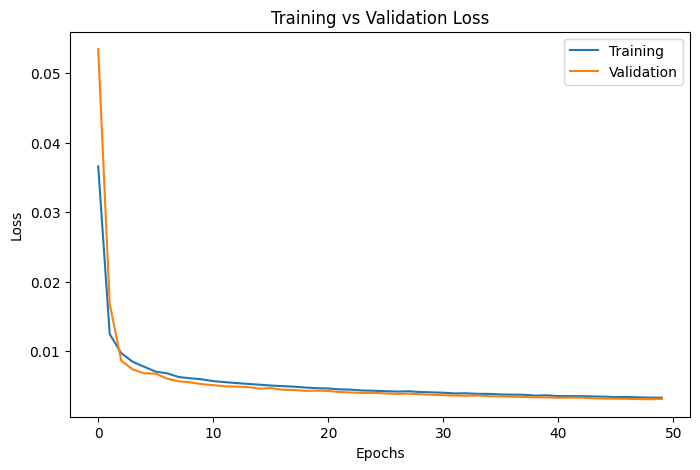

In [ ]:
# plot loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend(["Training", "Validation"])
plt.show()

In [ ]:
# Evaluate model
loss = autoencoder.evaluate(validation_generator)
print("Validation Loss:", loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0031
Validation Loss: 0.0031312957871705294


In [ ]:
# recinstruct model
images, _ = next(validation_generator)
reconstructed = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 823ms/step


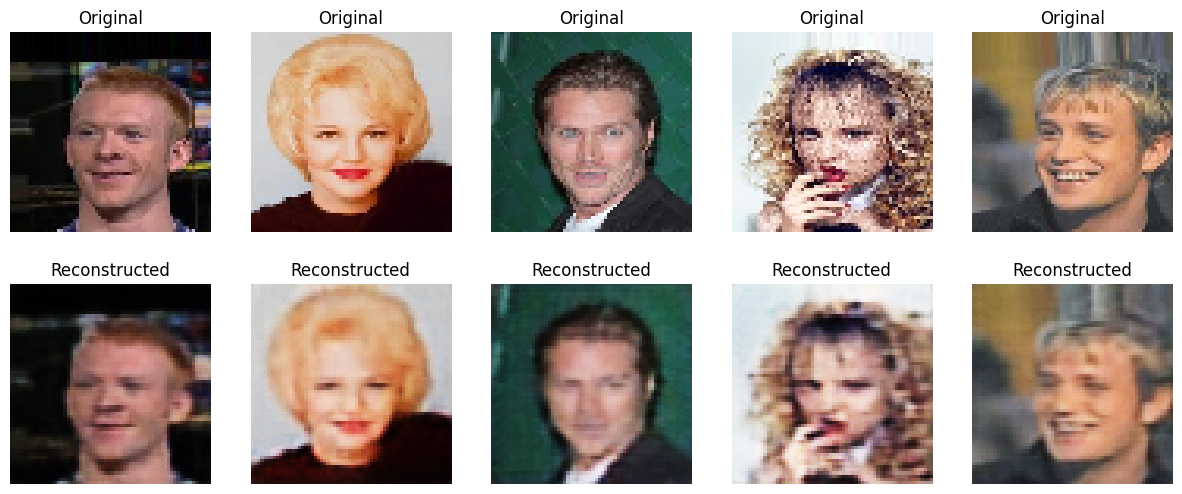

In [ ]:
# Display result
n = 5
plt.figure(figsize=(15,6))

for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("Original")
  plt.axis("off")
  plt.subplot(2,n,i+1+n)
  plt.imshow(reconstructed[i])
  plt.title("Reconstructed")
  plt.axis("off")
plt.show()


In [ ]:
# CNN RNN CODING
old_loss = 0.48
new_loss = 0.0033

improvement = ((old_loss - new_loss) / old_loss) * 100

print(f"Validation Loss Improved by: {improvement:.2f}%")

Validation Loss Improved by: 99.31%
